In [31]:
import json
import re
import numpy as np
import pandas as pd
import re
from scipy.stats import pointbiserialr, spearmanr, ttest_ind, mannwhitneyu
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import pingouin as pg
from tqdm import tqdm
from transformers import AutoTokenizer
import rich

In [32]:
with open('/data/user_data/wenkail/sotopia_diplomacy/processed_data_analysis/500_sample_with_taskeval_supply_center_qwen_judge.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

In [33]:
games_with_winner = []
for game in tqdm(data):
    last_phase = game['phases'][-1]
    centers = last_phase['state']['centers']
    game_with_winner = json.loads(json.dumps(game))
    game_with_winner['winner'] = []
    game_with_winner['losers'] = []
    for country, centers_list in centers.items():
        if len(centers_list) >= 18:
            game_with_winner['winner'] = country
        if len(centers_list) == 0:
            game_with_winner['losers'].append(country)
    if game_with_winner['winner'] != [] and game_with_winner['losers'] != []:
        games_with_winner.append(game_with_winner)

100%|██████████| 471/471 [00:13<00:00, 35.73it/s]


In [34]:
len(games_with_winner)

213

In [35]:
games_with_winner[0]

{'id': '1727',
 'map': 'standard',
 'rules': ['NO_PRESS', 'POWER_CHOICE'],
 'phases': [{'name': 'S1901M',
   'state': {'timestamp': 1711385725218381,
    'zobrist_hash': '1919110489198082658',
    'note': '',
    'name': 'S1901M',
    'units': {'AUSTRIA': ['A BUD', 'A VIE', 'F TRI'],
     'ENGLAND': ['F EDI', 'F LON', 'A LVP'],
     'FRANCE': ['F BRE', 'A MAR', 'A PAR'],
     'GERMANY': ['F KIE', 'A BER', 'A MUN'],
     'ITALY': ['F NAP', 'A ROM', 'A VEN'],
     'RUSSIA': ['A WAR', 'A MOS', 'F SEV', 'F STP/SC'],
     'TURKEY': ['F ANK', 'A CON', 'A SMY']},
    'retreats': {'AUSTRIA': {},
     'ENGLAND': {},
     'FRANCE': {},
     'GERMANY': {},
     'ITALY': {},
     'RUSSIA': {},
     'TURKEY': {}},
    'centers': {'AUSTRIA': ['BUD', 'TRI', 'VIE'],
     'ENGLAND': ['EDI', 'LON', 'LVP'],
     'FRANCE': ['BRE', 'MAR', 'PAR'],
     'GERMANY': ['BER', 'KIE', 'MUN'],
     'ITALY': ['NAP', 'ROM', 'VEN'],
     'RUSSIA': ['MOS', 'SEV', 'STP', 'WAR'],
     'TURKEY': ['ANK', 'CON', 'SMY']},
  

In [55]:
# 统计winner和loser，并且区分保存，方便后续对比分析
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

# 加载llama3-8b tokenizer
llama3_tokenizer = AutoTokenizer.from_pretrained("/data/models/huggingface/meta-llama/Llama-3.1-8B-Instruct/")

feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

def extract_answers_after_think(s):
    if not s or not isinstance(s, str):
        return []
    lines = s.strip().split('\n')
    results = []
    for line in lines:
        m = re.search(r'(yes|no)\s*$', line.strip().lower())
        if m:
            results.append(m.group(1))
    return results

def extract_year(phase_name):
    m = re.match(r'[SWF](\d{4})', phase_name)
    if m:
        return int(m.group(1))
    return None

def count_sentences(text):
    if not text or not isinstance(text, str):
        return 0
    return len(sent_tokenize(text))

def count_tokens(text, tokenizer):
    if not text or not isinstance(text, str):
        return 0
    return len(tokenizer.encode(text))

winner_yearly_stats = []
loser_yearly_stats = []

for game in tqdm(games_with_winner):
    winner = game['winner']
    losers = game['losers']
    game_id = game.get('id')
    phases = game.get('phases', [])
    # 按year聚合phase
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        year = extract_year(phase_name)
        if year is None:
            continue
        year_to_phases.setdefault(year, []).append(phase)
    for year, year_phases in year_to_phases.items():
        # winner每年所有phase的center_count, center_increase, taskeval
        center_counts = []
        center_increases = []
        taskevals = []
        winner_messages = []
        feature_counts = np.zeros(8, dtype=int)
        for phase in year_phases:
            center_info = phase.get('center_info', {})
            taskeval_info = phase.get('taskeval', {})
            if winner in center_info:
                center_counts.append(center_info[winner].get('center_count', np.nan))
                center_increases.append(center_info[winner].get('center_increase', np.nan))
            if winner in taskeval_info:
                taskevals.append(taskeval_info[winner])
            # 只统计winner作为sender的message
            for msg in phase.get('messages', []):
                if msg is not None and msg.get('sender') == winner:
                    winner_messages.append(msg.get('message', ''))
                    s = msg.get('llm_judgement')
                    if not s:
                        continue
                    matches = extract_answers_after_think(s)
                    if len(matches) != 8:
                        continue
                    for i, val in enumerate(matches):
                        if val == 'yes':
                            feature_counts[i] += 1
        # winner聚合
        # 新增判断：如果winner_messages为空，则不保存该行
        if len(winner_messages) > 0:
            all_messages_str = "\n".join(winner_messages)
            stat = {
                'game_id': game_id,
                'role': 'winner',
                'country': winner,
                'year': year,
                'center_count_mean': center_counts[-1] if center_counts else np.nan,
                'center_increase_sum': np.nansum(center_increases) if center_increases else np.nan,
                'taskeval_mean': np.nanmean(taskevals) if taskevals else np.nan,
                'message_count': len(winner_messages),
                'all_messages': all_messages_str,
                'all_messages_sentence_count': count_sentences(all_messages_str),
                'all_messages_token_count': count_tokens(all_messages_str, llama3_tokenizer)
            }
            for i in range(8):
                stat[f'feature_{i}_yes_count'] = feature_counts[i]
            winner_yearly_stats.append(stat)

        # 对每个loser也做同样的统计
        for loser in losers:
            center_counts = []
            center_increases = []
            taskevals = []
            loser_messages = []
            feature_counts = np.zeros(8, dtype=int)
            for phase in year_phases:
                center_info = phase.get('center_info', {})
                taskeval_info = phase.get('taskeval', {})
                if loser in center_info:
                    center_counts.append(center_info[loser].get('center_count', np.nan))
                    center_increases.append(center_info[loser].get('center_increase', np.nan))
                if loser in taskeval_info:
                    taskevals.append(taskeval_info[loser])
                for msg in phase.get('messages', []):
                    if msg is not None and msg.get('sender') == loser:
                        loser_messages.append(msg.get('message', ''))
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                feature_counts[i] += 1
            # 新增判断：如果loser_messages为空，则不保存该行
            if len(loser_messages) > 0:
                all_messages_str = "\n".join(loser_messages)
                stat = {
                    'game_id': game_id,
                    'role': 'loser',
                    'country': loser,
                    'year': year,
                    'center_count_mean': center_counts[-1] if center_counts else np.nan,
                    'center_increase_sum': np.nansum(center_increases) if center_increases else np.nan,
                    'taskeval_mean': np.nanmean(taskevals) if taskevals else np.nan,
                    'message_count': len(loser_messages),
                    'all_messages': all_messages_str,
                    'all_messages_sentence_count': count_sentences(all_messages_str),
                    'all_messages_token_count': count_tokens(all_messages_str, llama3_tokenizer)
                }
                for i in range(8):
                    stat[f'feature_{i}_yes_count'] = feature_counts[i]
                loser_yearly_stats.append(stat)

# winner/loser分别保存DataFrame，方便后续对比
df_winner_yearly = pd.DataFrame(winner_yearly_stats)
df_loser_yearly = pd.DataFrame(loser_yearly_stats)

# 只对feature count列做rename
feature_count_rename = {f'feature_{i}_yes_count': feature_name_map[f'feature_{i}_yes_binary'] + "_count" for i in range(8)}
df_winner_yearly = df_winner_yearly.rename(columns=feature_count_rename)
df_loser_yearly = df_loser_yearly.rename(columns=feature_count_rename)


[nltk_data] Downloading package punkt to /home/wenkail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 213/213 [00:13<00:00, 15.65it/s]


In [57]:
df_loser_yearly
# df_winner_yearly

,game_id,role,country,year,center_count_mean,center_increase_sum,taskeval_mean,message_count,all_messages,all_messages_sentence_count,all_messages_token_count,1. Game-Move_count,2. Reasoning_count,3. Rapport_count,4. Apologies_count,5. Compliment_count,6. Personal-Thoughts_count,7. Reassurance_count,8. Share-Information_count
0,1727,loser,AUSTRIA,1901,4,1,-0.006345,9,dude fuck u\r\nhow about [1419495] split serbi...,13,238,1,0,0,0,0,0,0,1
1,1727,loser,GERMANY,1901,3,0,0.017162,7,"DMZ for TYR, BOH ? agree?\r\nwhat's your probl...",13,114,2,0,0,0,0,0,0,0
2,1727,loser,ITALY,1901,4,1,0.030454,5,Alliance against France?\r\nMaybe\r\nOk\r\nJus...,2,23,1,0,0,0,0,0,0,0
3,1727,loser,RUSSIA,1901,7,3,0.057595,1,[501416] black sea?\r,1,9,0,0,0,0,0,0,0,0
4,1727,loser,AUSTRIA,1902,5,1,0.027607,3,dude i need ur support into rumaina from serbi...,6,64,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3508,90367,loser,AUSTRIA,1906,4,-1,0.010528,6,"Help me take Sev?\r\nActually, when you take S...",8,77,3,0,0,0,0,0,0,0
3509,90367,loser,AUSTRIA,1907,4,0,-0.006778,3,Ok Ukraine to Sev.\nAre you going to be able t...,4,32,1,0,0,0,0,0,0,0
3510,90367,loser,AUSTRIA,1908,1,-3,0.007271,5,Looks like we need to stop Germany. Can you ba...,9,90,3,0,0,0,0,0,0,1
3511,90367,loser,AUSTRIA,1909,0,-1,0.001188,9,Should I head into Vienna or should I try for ...,12,143,4,1,0,0,0,0,0,0


In [51]:
# # ========================================================
# # core_analysis.py  –  长期轨迹 + 多特征对照 + 扩展指标
# # ========================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path

# # --------------------------------------------------------
# # 0) 参数区
# # --------------------------------------------------------
# YEAR_COL        = "year"
# GAME_ID_COL     = "game_id"
# SUPPLY_COL      = "center_count_mean"     # 当前拥有 supply centers
# SUPPLY_GAIN_COL = "center_increase_sum"   # 当年净增 supply centers

# FEATURE_COLS = [   # 所有计数字段
#     "1. Game-Move_count", "2. Reasoning_count", "3. Rapport_count",
#     "4. Apologies_count", "5. Compliment_count", "6. Personal-Thoughts_count",
#     "7. Reassurance_count", "8. Share-Information_count"
# ]

# SEGMENT_BINS = {"early": (1901, 1903), "mid": (1904, 1906), "late": (1907, 1910)}

# # --------------------------------------------------------
# # 1) 主函数：预处理 + 派生列
# # --------------------------------------------------------
# def preprocess(df_raw: pd.DataFrame) -> pd.DataFrame:
#     """派生 rolling / slope 列并返回新 DF（不再累计cumsum，直接用mean value）"""
#     df = df_raw.copy().sort_values([GAME_ID_COL, YEAR_COL]).reset_index(drop=True)
#     g = df.groupby(GAME_ID_COL)

#     # Supply/feature rolling mean/slope
#     for col in [SUPPLY_COL, SUPPLY_GAIN_COL] + FEATURE_COLS:
#         df[f"roll_{col}"]  = g[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
#         df[f"slope_{col}"] = g[col].diff().rolling(3, min_periods=1).mean().reset_index(0, drop=True)
#     return df

# # --------------------------------------------------------
# # 2) 可视化工具
# # --------------------------------------------------------
# def plot_game_pair(df, game_id, feature, save_dir=None):
#     """双 Y 轴：Supply mean vs 任意特征滚动平均（均为mean value，不再累计）"""
#     gdf = df[df[GAME_ID_COL] == game_id]

#     fig, ax1 = plt.subplots(figsize=(10, 5))
#     ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL], marker="o",
#              label="Supply Centers (mean)")
#     ax1.set_ylabel("Supply Centers (mean)")
#     ax1.set_xlabel("Year")

#     ax2 = ax1.twinx()
#     ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feature}"], color="tab:red",
#              marker="s", label=f"Rolling {feature}")
#     ax2.set_ylabel(f"{feature} (3-yr MA)")

#     lines, labels = ax1.get_legend_handles_labels()
#     l2, lab2      = ax2.get_legend_handles_labels()
#     ax1.legend(lines + l2, labels + lab2, loc="upper left")
#     ax1.set_title(f"Game {game_id}: Supply (mean) vs {feature}")
#     ax1.grid(alpha=.3)
#     plt.tight_layout()

#     if save_dir:
#         Path(save_dir).mkdir(exist_ok=True)
#         fname = Path(save_dir) / f"{game_id}_{feature.replace(' ', '_')}.png"
#         plt.savefig(fname, dpi=200)
#     plt.close()

# def plot_all_features_grid(df, game_id, cols=FEATURE_COLS, ncols=2):
#     """一次性画完 Supply(mean)-vs-所有特征的网格图（只显示不保存）"""
#     n = len(cols)
#     nrows = int(np.ceil(n / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
#                              sharex=True)
#     axes = axes.flatten()

#     for i, feat in enumerate(cols):
#         gdf = df[df[GAME_ID_COL] == game_id]
#         ax1 = axes[i]
#         ax2 = ax1.twinx()

#         ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL],
#                  marker="o", label="Supply (mean)", color="tab:blue")
#         ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feat}"],
#                  marker="s", label=feat, color="tab:red")

#         ax1.set_title(feat, fontsize=10)
#         ax1.grid(alpha=.2)
#         if i % ncols == 0:     # 左列才写 y 轴
#             ax1.set_ylabel("Supply (mean)")
#         if i // ncols == nrows-1:
#             ax1.set_xlabel("Year")

#     # 清空多余子图
#     for j in range(i+1, len(axes)):
#         axes[j].set_visible(False)
#     plt.suptitle(f"Game {game_id}: Supply (mean) vs All Features", y=1.02, fontsize=14)
#     plt.tight_layout()
#     plt.show()

# # --------------------------------------------------------
# # 新增：所有game的平均曲线（mean value，不累计）
# # --------------------------------------------------------
# def plot_mean_curves(df, feature_cols=FEATURE_COLS, supply_col=SUPPLY_COL, year_col=YEAR_COL, game_id_col=GAME_ID_COL):
#     """
#     画出所有game的平均曲线（按year对齐），包括supply mean和各特征的rolling均值。
#     """
#     # 先确保有派生列
#     needed_cols = [supply_col] + [f"roll_{col}" for col in feature_cols]
#     for col in needed_cols:
#         if col not in df.columns:
#             raise ValueError(f"请先对df运行preprocess，缺少列: {col}")

#     # 计算每年所有game的均值和标准差
#     mean_df = df.groupby(year_col).agg(
#         **{f"mean_{supply_col}": (supply_col, "mean")},
#         **{f"std_{supply_col}": (supply_col, "std")},
#         **{f"mean_roll_{col}": (f"roll_{col}", "mean") for col in feature_cols},
#         **{f"std_roll_{col}": (f"roll_{col}", "std") for col in feature_cols},
#     ).reset_index()

#     # 画supply mean曲线
#     plt.figure(figsize=(8, 5))
#     plt.plot(mean_df[year_col], mean_df[f"mean_{supply_col}"], marker="o", label="Supply (mean)")
#     plt.fill_between(mean_df[year_col],
#                      mean_df[f"mean_{supply_col}"] - mean_df[f"std_{supply_col}"],
#                      mean_df[f"mean_{supply_col}"] + mean_df[f"std_{supply_col}"],
#                      color="tab:blue", alpha=0.2, label="±1 std")
#     plt.xlabel("Year")
#     plt.ylabel("Supply Centers (mean)")
#     plt.title("All Games: Mean Supply Centers by Year")
#     plt.legend()
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     # 画所有特征的rolling均值曲线
#     n = len(feature_cols)
#     ncols = 2
#     nrows = int(np.ceil(n / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
#     axes = axes.flatten()
#     for i, feat in enumerate(feature_cols):
#         ax = axes[i]
#         mean_col = f"mean_roll_{feat}"
#         std_col = f"std_roll_{feat}"
#         ax.plot(mean_df[year_col], mean_df[mean_col], marker="s", color="tab:red", label="Mean (3-yr MA)")
#         ax.fill_between(mean_df[year_col],
#                         mean_df[mean_col] - mean_df[std_col],
#                         mean_df[mean_col] + mean_df[std_col],
#                         color="tab:red", alpha=0.15, label="±1 std")
#         ax.set_title(feat, fontsize=10)
#         ax.grid(alpha=0.2)
#         if i % ncols == 0:
#             ax.set_ylabel("Mean (3-yr MA)")
#         if i // ncols == nrows-1:
#             ax.set_xlabel("Year")
#         ax.legend(fontsize=8)
#     # 清空多余子图
#     for j in range(i+1, len(axes)):
#         axes[j].set_visible(False)
#     plt.suptitle("All Games: Mean Rolling Feature Curves by Year", y=1.02, fontsize=14)
#     plt.tight_layout()
#     plt.show()

# # --------------------------------------------------------
# # 3) 批量导图 & 滞后相关
# # --------------------------------------------------------
# def export_all_games(df, out_dir="plots"):
#     """为每局游戏、每个特征都画图并保存到 out_dir"""
#     for gid in df[GAME_ID_COL].unique():
#         for feat in FEATURE_COLS:
#             plot_game_pair(df, gid, feat, save_dir=out_dir)

# def lag_correlation(df, feature, lag=1):
#     """
#     滞后相关: 特征计数 vs 下一年 supply_gain。
#     lag=1 表示 corr( feature_t , supply_gain_{t+1} ).
#     返回各局的相关系数 Series.
#     """
#     def _one_game(g):
#         return g[feature].shift(0).corr(g[SUPPLY_GAIN_COL].shift(-lag))
#     return df.groupby(GAME_ID_COL).apply(_one_game)

# # --------------------------------------------------------
# # 4) 分段占比（早/中/晚期）
# # --------------------------------------------------------
# def segment_ratio(df):
#     """返回每局早/中/晚期各特征占比分布"""
#     seg_list = []
#     for seg, (lo, hi) in SEGMENT_BINS.items():
#         tmp = df[(df[YEAR_COL] >= lo) & (df[YEAR_COL] <= hi)]
#         tot  = tmp.groupby(GAME_ID_COL)[FEATURE_COLS].sum()
#         ratio = tot.div(tot.sum(axis=1), axis=0)
#         ratio["segment"] = seg
#         seg_list.append(ratio)
#     return pd.concat(seg_list).reset_index()

# # --------------------------------------------------------
# # 5) DEMO
# # --------------------------------------------------------
# if __name__ == "__main__":
#     # 假设你在同目录提前加载了 df_winner_yearly
#     df_winner_yearly = globals().get("df_winner_yearly")  # Notebook 中可直接用已存在变量
#     if df_winner_yearly is None:
#         raise ValueError("请先定义 df_winner_yearly 再运行脚本！")

#     df_proc = preprocess(df_winner_yearly)

#     # ① 单局所有特征网格图
#     example_game = df_proc[GAME_ID_COL].iloc[0]
#     plot_all_features_grid(df_proc, example_game)

#     # ①b 新增：所有game的平均曲线
#     plot_mean_curves(df_proc)

#     # ② 批量导出 (可注释)
#     # export_all_games(df_proc, out_dir="plots_supply_vs_feats")

#     # ③ 计算滞后相关
#     corr_table = {feat: lag_correlation(df_proc, feat, lag=1) for feat in FEATURE_COLS}
#     corr_df = pd.DataFrame(corr_table)
#     print("\nLag-1 correlation (feature_t  vs  supply_gain_{t+1})")
#     print(corr_df.head())

#     # ④ 分段占比
#     seg_ratio_df = segment_ratio(df_proc)
#     print("\nEarly / Mid / Late  segment feature ratios")
#     print(seg_ratio_df.head())


In [52]:
# ========================================================
# core_analysis.py  –  长期轨迹 + 多特征对照 + 扩展指标
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --------------------------------------------------------
# 0) 参数区
# --------------------------------------------------------
YEAR_COL        = "year"
GAME_ID_COL     = "game_id"
SUPPLY_COL      = "center_count_mean"     # 当前拥有 supply centers
SUPPLY_GAIN_COL = "center_increase_sum"   # 当年净增 supply centers

FEATURE_COLS = [   # 所有计数字段
    "1. Game-Move_count", "2. Reasoning_count", "3. Rapport_count",
    "4. Apologies_count", "5. Compliment_count", "6. Personal-Thoughts_count",
    "7. Reassurance_count", "8. Share-Information_count"
]

SEGMENT_BINS = {"early": (1901, 1903), "mid": (1904, 1906), "late": (1907, 1910)}

# --------------------------------------------------------
# 1) 主函数：预处理 + 派生列
# --------------------------------------------------------
def preprocess(df_raw: pd.DataFrame) -> pd.DataFrame:
    """派生 rolling / slope 列并返回新 DF（不再累计cumsum，直接用mean value）"""
    df = df_raw.copy().sort_values([GAME_ID_COL, YEAR_COL]).reset_index(drop=True)
    g = df.groupby(GAME_ID_COL)

    # Supply/feature rolling mean/slope
    for col in [SUPPLY_COL, SUPPLY_GAIN_COL] + FEATURE_COLS:
        df[f"roll_{col}"]  = g[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
        df[f"slope_{col}"] = g[col].diff().rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    return df

# --------------------------------------------------------
# 2) 可视化工具
# --------------------------------------------------------
def plot_game_pair(df, game_id, feature, save_dir=None):
    """双 Y 轴：Supply mean vs 任意特征滚动平均（均为mean value，不再累计）"""
    gdf = df[df[GAME_ID_COL] == game_id]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL], marker="o",
             label="Supply Centers (mean)")
    ax1.set_ylabel("Supply Centers (mean)")
    ax1.set_xlabel("Year")

    ax2 = ax1.twinx()
    ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feature}"], color="tab:red",
             marker="s", label=f"Rolling {feature}")
    ax2.set_ylabel(f"{feature} (3-yr MA)")

    lines, labels = ax1.get_legend_handles_labels()
    l2, lab2      = ax2.get_legend_handles_labels()
    ax1.legend(lines + l2, labels + lab2, loc="upper left")
    ax1.set_title(f"Game {game_id}: Supply (mean) vs {feature}")
    ax1.grid(alpha=.3)
    plt.tight_layout()

    if save_dir:
        Path(save_dir).mkdir(exist_ok=True)
        fname = Path(save_dir) / f"{game_id}_{feature.replace(' ', '_')}.png"
        plt.savefig(fname, dpi=200)
    plt.close()

def plot_all_features_grid(df, game_id, cols=FEATURE_COLS, ncols=2):
    """一次性画完 Supply(mean)-vs-所有特征的网格图（只显示不保存）"""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows),
                             sharex=True)
    axes = axes.flatten()

    for i, feat in enumerate(cols):
        gdf = df[df[GAME_ID_COL] == game_id]
        ax1 = axes[i]
        ax2 = ax1.twinx()

        ax1.plot(gdf[YEAR_COL], gdf[SUPPLY_COL],
                 marker="o", label="Supply (mean)", color="tab:blue")
        ax2.plot(gdf[YEAR_COL], gdf[f"roll_{feat}"],
                 marker="s", label=feat, color="tab:red")

        ax1.set_title(feat, fontsize=10)
        ax1.grid(alpha=.2)
        if i % ncols == 0:     # 左列才写 y 轴
            ax1.set_ylabel("Supply (mean)")
        if i // ncols == nrows-1:
            ax1.set_xlabel("Year")

    # 清空多余子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f"Game {game_id}: Supply (mean) vs All Features", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 新增：所有game的平均曲线（mean value，不累计）
# --------------------------------------------------------
def plot_mean_curves(df, feature_cols=FEATURE_COLS, supply_col=SUPPLY_COL, year_col=YEAR_COL, game_id_col=GAME_ID_COL):
    """
    画出所有game的平均曲线（按year对齐），包括supply mean和各特征的rolling均值。
    """
    # 先确保有派生列
    needed_cols = [supply_col] + [f"roll_{col}" for col in feature_cols]
    for col in needed_cols:
        if col not in df.columns:
            raise ValueError(f"请先对df运行preprocess，缺少列: {col}")

    # 计算每年所有game的均值和标准差
    mean_df = df.groupby(year_col).agg(
        **{f"mean_{supply_col}": (supply_col, "mean")},
        **{f"std_{supply_col}": (supply_col, "std")},
        **{f"mean_roll_{col}": (f"roll_{col}", "mean") for col in feature_cols},
        **{f"std_roll_{col}": (f"roll_{col}", "std") for col in feature_cols},
    ).reset_index()

    # 画supply mean曲线
    plt.figure(figsize=(8, 5))
    plt.plot(mean_df[year_col], mean_df[f"mean_{supply_col}"], marker="o", label="Supply (mean)")
    plt.fill_between(mean_df[year_col],
                     mean_df[f"mean_{supply_col}"] - mean_df[f"std_{supply_col}"],
                     mean_df[f"mean_{supply_col}"] + mean_df[f"std_{supply_col}"],
                     color="tab:blue", alpha=0.2, label="±1 std")
    plt.xlabel("Year")
    plt.ylabel("Supply Centers (mean)")
    plt.title("All Games: Mean Supply Centers by Year")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 画所有特征的rolling均值曲线
    n = len(feature_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    for i, feat in enumerate(feature_cols):
        ax = axes[i]
        mean_col = f"mean_roll_{feat}"
        std_col = f"std_roll_{feat}"
        ax.plot(mean_df[year_col], mean_df[mean_col], marker="s", color="tab:red", label="Mean (3-yr MA)")
        ax.fill_between(mean_df[year_col],
                        mean_df[mean_col] - mean_df[std_col],
                        mean_df[mean_col] + mean_df[std_col],
                        color="tab:red", alpha=0.15, label="±1 std")
        ax.set_title(feat, fontsize=10)
        ax.grid(alpha=0.2)
        if i % ncols == 0:
            ax.set_ylabel("Mean (3-yr MA)")
        if i // ncols == nrows-1:
            ax.set_xlabel("Year")
        ax.legend(fontsize=8)
    # 清空多余子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("All Games: Mean Rolling Feature Curves by Year", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------
# 3) 批量导图 & 滞后相关
# --------------------------------------------------------
def export_all_games(df, out_dir="plots"):
    """为每局游戏、每个特征都画图并保存到 out_dir"""
    for gid in df[GAME_ID_COL].unique():
        for feat in FEATURE_COLS:
            plot_game_pair(df, gid, feat, save_dir=out_dir)

def lag_correlation(df, feature, lag=1):
    """
    滞后相关: 特征计数 vs 下一年 supply_gain。
    lag=1 表示 corr( feature_t , supply_gain_{t+1} ).
    返回各局的相关系数 Series.
    """
    def _one_game(g):
        return g[feature].shift(0).corr(g[SUPPLY_GAIN_COL].shift(-lag))
    return df.groupby(GAME_ID_COL).apply(_one_game)

# --------------------------------------------------------
# 4) 分段占比（早/中/晚期）
# --------------------------------------------------------
def segment_ratio(df):
    """返回每局早/中/晚期各特征占比分布"""
    seg_list = []
    for seg, (lo, hi) in SEGMENT_BINS.items():
        tmp = df[(df[YEAR_COL] >= lo) & (df[YEAR_COL] <= hi)]
        tot  = tmp.groupby(GAME_ID_COL)[FEATURE_COLS].sum()
        ratio = tot.div(tot.sum(axis=1), axis=0)
        ratio["segment"] = seg
        seg_list.append(ratio)
    return pd.concat(seg_list).reset_index()

# # --------------------------------------------------------
# # 5) DEMO
# # --------------------------------------------------------
# if __name__ == "__main__":
#     # 假设你在同目录提前加载了 df_winner_yearly
#     df_winner_yearly = globals().get("df_loser_yearly")  # Notebook 中可直接用已存在变量
#     if df_winner_yearly is None:
#         raise ValueError("请先定义 df_loser_yearly 再运行脚本！")

#     df_proc = preprocess(df_winner_yearly)

#     # ① 单局所有特征网格图
#     example_game = df_proc[GAME_ID_COL].iloc[0]
#     plot_all_features_grid(df_proc, example_game)

#     # ①b 新增：所有game的平均曲线
#     plot_mean_curves(df_proc)

#     # ② 批量导出 (可注释)
#     # export_all_games(df_proc, out_dir="plots_supply_vs_feats")

#     # ③ 计算滞后相关
#     corr_table = {feat: lag_correlation(df_proc, feat, lag=1) for feat in FEATURE_COLS}
#     corr_df = pd.DataFrame(corr_table)
#     print("\nLag-1 correlation (feature_t  vs  supply_gain_{t+1})")
#     print(corr_df.head())

#     # ④ 分段占比
#     seg_ratio_df = segment_ratio(df_proc)
#     print("\nEarly / Mid / Late  segment feature ratios")
#     print(seg_ratio_df.head())


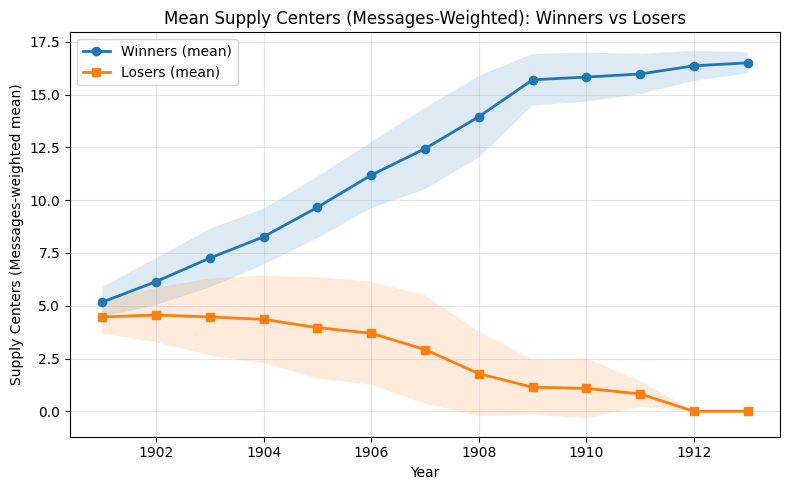

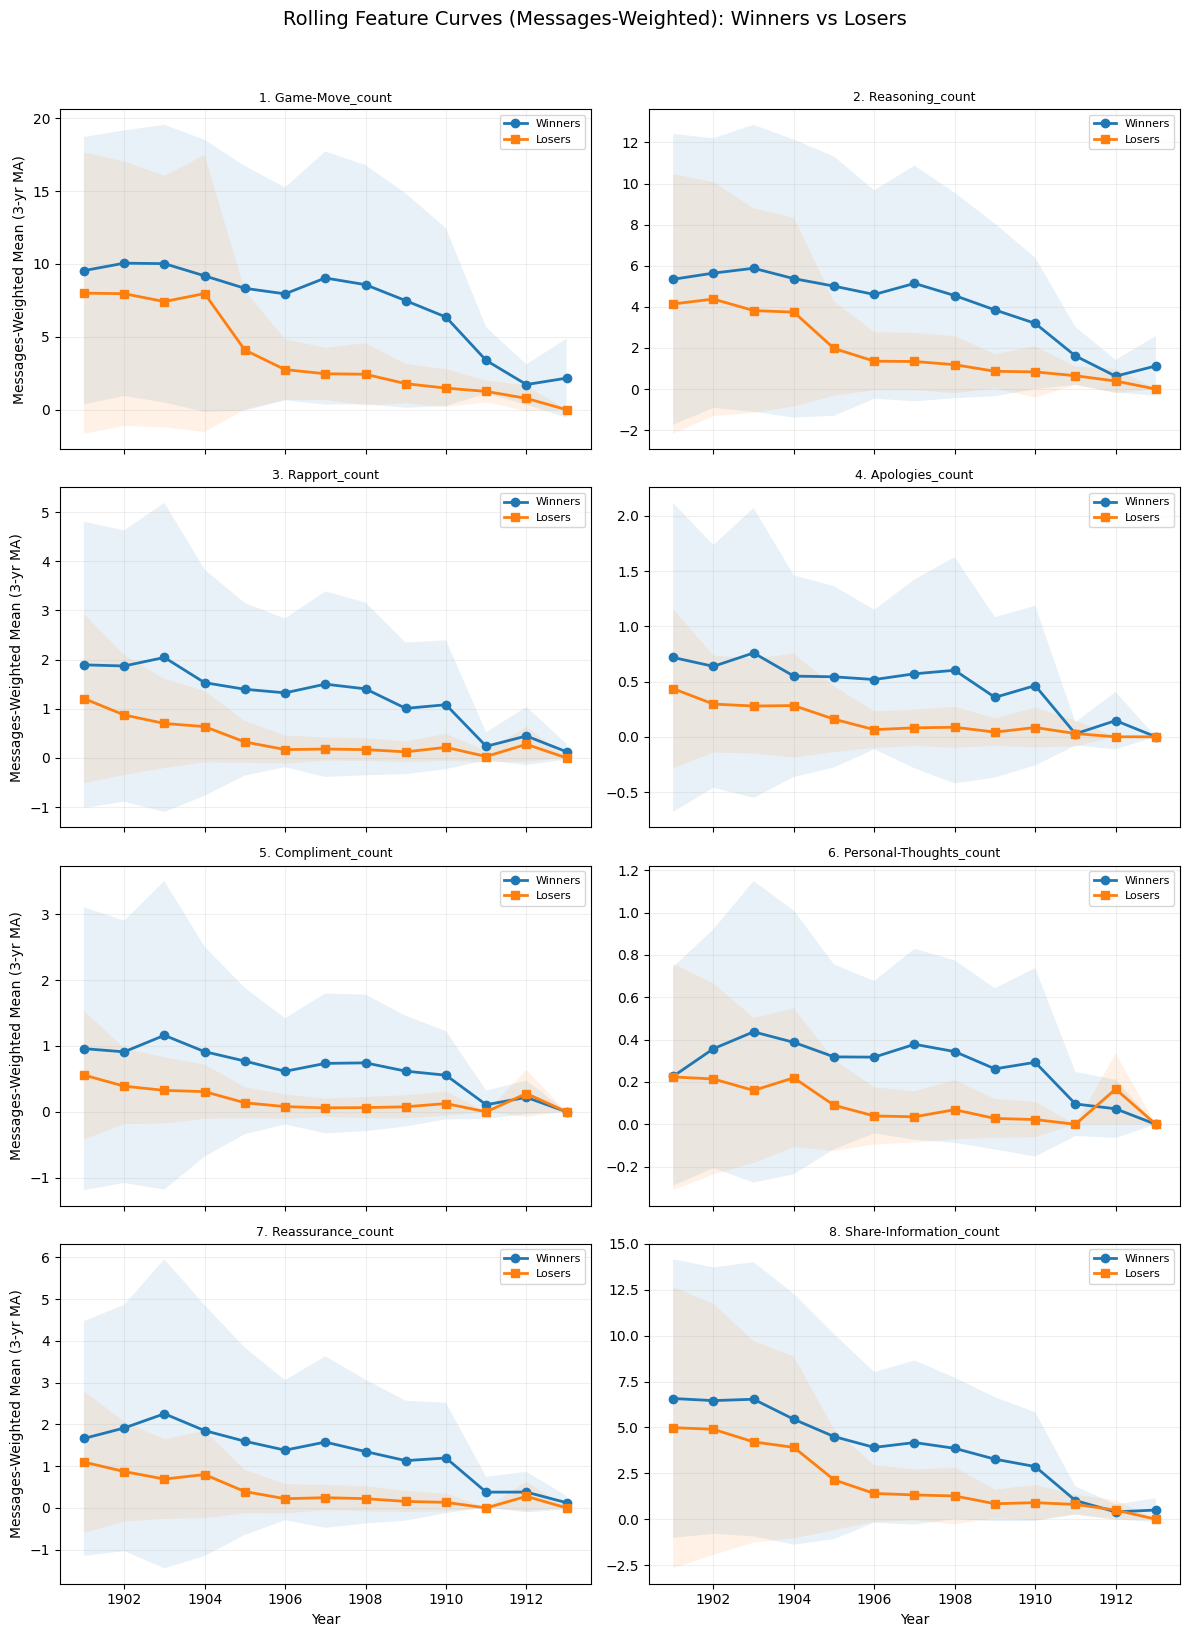

In [59]:
# ============================================
# 新增：赢家 vs 败者 的对比曲线（基于消息加权平均）
# ============================================
def _yearly_messages_weighted_mean_std(df, feature_cols, supply_col, year_col, messages_col="message_count"):
    """
    内部工具：返回按年聚合后的 messages-weighted mean/std DataFrame
    - mean: sum(feature * message_count) / sum(message_count)
    - std: sqrt( sum(message_count * (feature - mean)^2) / sum(message_count) )
    """
    # 先确保所有需要的列都存在
    df = df.copy()
    if messages_col not in df.columns:
        raise ValueError(f"DataFrame 缺少 {messages_col} 列")
    # 计算每个 feature * message_count
    for c in feature_cols:
        df[f"roll_{c}_x_msg"] = df[f"roll_{c}"] * df[messages_col]
    # 计算 supply * message_count
    df[f"{supply_col}_x_msg"] = df[supply_col] * df[messages_col]

    def weighted_mean_std(group, value_col, weight_col):
        v = group[value_col]
        w = group[weight_col]
        mean = (v * w).sum() / w.sum() if w.sum() > 0 else np.nan
        # weighted std: sqrt( sum(w * (v-mean)^2) / sum(w) )
        std = np.sqrt(((w * (v - mean) ** 2).sum()) / w.sum()) if w.sum() > 0 else np.nan
        return pd.Series({"mean": mean, "std": std})

    results = []
    for year, group in df.groupby(year_col):
        row = {year_col: year}
        # supply
        res = weighted_mean_std(group, supply_col, messages_col)
        row[f"mean_{supply_col}_messages_weight"] = res["mean"]
        row[f"std_{supply_col}_messages_weight"] = res["std"]
        # features
        for c in feature_cols:
            res_feat = weighted_mean_std(group, f"roll_{c}", messages_col)
            row[f"mean_roll_{c}_messages_weight"] = res_feat["mean"]
            row[f"std_roll_{c}_messages_weight"] = res_feat["std"]
        results.append(row)
    return pd.DataFrame(results)

def plot_mean_curves_messages_weight_compare(
    df_win, df_loss, *,                   # 已 preprocess 的 DF
    feature_cols=FEATURE_COLS,
    supply_col=SUPPLY_COL,
    year_col=YEAR_COL,
    label_win="Winners", label_loss="Losers",
    messages_col="message_count"
):
    """
    把 winner / loser 的平均 Supply & Feature 曲线画在同一张图上。
    均值为 messages-weighted mean。
    先调用 preprocess，再传进来！
    """
    # --------- 计算消息加权均值与方差 ---------
    mean_win  = _yearly_messages_weighted_mean_std(df_win,  feature_cols, supply_col, year_col, messages_col)
    mean_loss = _yearly_messages_weighted_mean_std(df_loss, feature_cols, supply_col, year_col, messages_col)

    # --------- ① Supply 对比 ---------
    plt.figure(figsize=(8, 5))
    plt.plot(mean_win[year_col],  mean_win[f"mean_{supply_col}_messages_weight"],
             marker="o", label=f"{label_win} (mean)",  linewidth=2)
    plt.plot(mean_loss[year_col], mean_loss[f"mean_{supply_col}_messages_weight"],
             marker="s", label=f"{label_loss} (mean)", linewidth=2)
    # 阴影显示 ±1 std
    plt.fill_between(mean_win[year_col],
                     mean_win[f"mean_{supply_col}_messages_weight"]  - mean_win[f"std_{supply_col}_messages_weight"],
                     mean_win[f"mean_{supply_col}_messages_weight"]  + mean_win[f"std_{supply_col}_messages_weight"],
                     alpha=0.15)
    plt.fill_between(mean_loss[year_col],
                     mean_loss[f"mean_{supply_col}_messages_weight"] - mean_loss[f"std_{supply_col}_messages_weight"],
                     mean_loss[f"mean_{supply_col}_messages_weight"] + mean_loss[f"std_{supply_col}_messages_weight"],
                     alpha=0.15)
    plt.xlabel("Year"); plt.ylabel("Supply Centers (Messages-weighted mean)")
    plt.title("Mean Supply Centers (Messages-Weighted): Winners vs Losers")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # --------- ② 各特征对比 ---------
    n = len(feature_cols); ncols = 2; nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    for i, feat in enumerate(feature_cols):
        ax = axes[i]
        w_mean = mean_win [f"mean_roll_{feat}_messages_weight"]; w_std = mean_win [f"std_roll_{feat}_messages_weight"]
        l_mean = mean_loss[f"mean_roll_{feat}_messages_weight"]; l_std = mean_loss[f"std_roll_{feat}_messages_weight"]
        ax.plot(mean_win[year_col],  w_mean, marker="o", label=label_win,  linewidth=2)
        ax.plot(mean_loss[year_col], l_mean, marker="s", label=label_loss, linewidth=2)
        ax.fill_between(mean_win[year_col],  w_mean-w_std, w_mean+w_std, alpha=.10)
        ax.fill_between(mean_loss[year_col], l_mean-l_std, l_mean+l_std, alpha=.10)
        ax.set_title(feat, fontsize=9); ax.grid(alpha=.2)
        if i % ncols == 0: ax.set_ylabel("Messages-Weighted Mean (3-yr MA)")
        if i // ncols == nrows-1: ax.set_xlabel("Year")
        ax.legend(fontsize=8)
    # 清掉空白子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Rolling Feature Curves (Messages-Weighted): Winners vs Losers", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()


# ============================================
# DEMO: 在主函数里调用
# ============================================
if __name__ == "__main__":
    # 假设你已经在 Notebook / 脚本里准备好 df_winner_yearly 和 df_loser_yearly
    if "df_winner_yearly" not in globals() or "df_loser_yearly" not in globals():
        raise ValueError("请先定义 df_winner_yearly 与 df_loser_yearly！")

    # 1) 预处理
    df_win_proc  = preprocess(df_winner_yearly)
    df_loss_proc = preprocess(df_loser_yearly)

    # 2) 赢家-败者平均曲线对比（基于消息加权平均）
    plot_mean_curves_messages_weight_compare(df_win_proc, df_loss_proc)

    # 其它分析（如滞后相关、分段占比等）也可以分别对 df_win_proc / df_loss_proc 调用


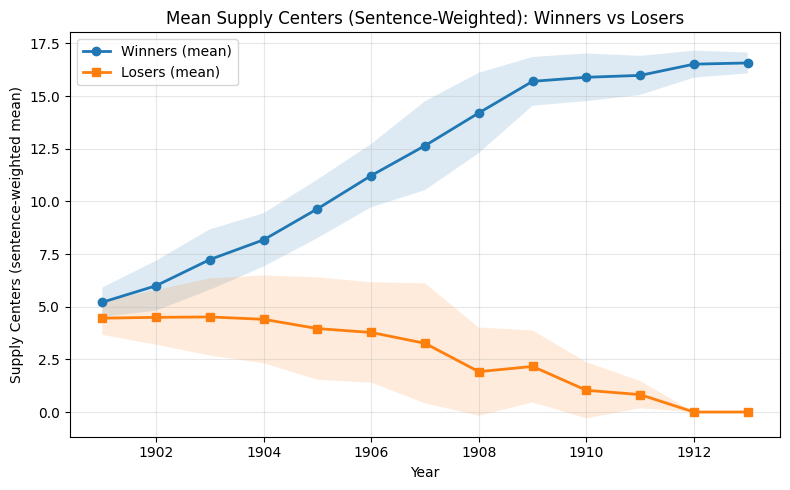

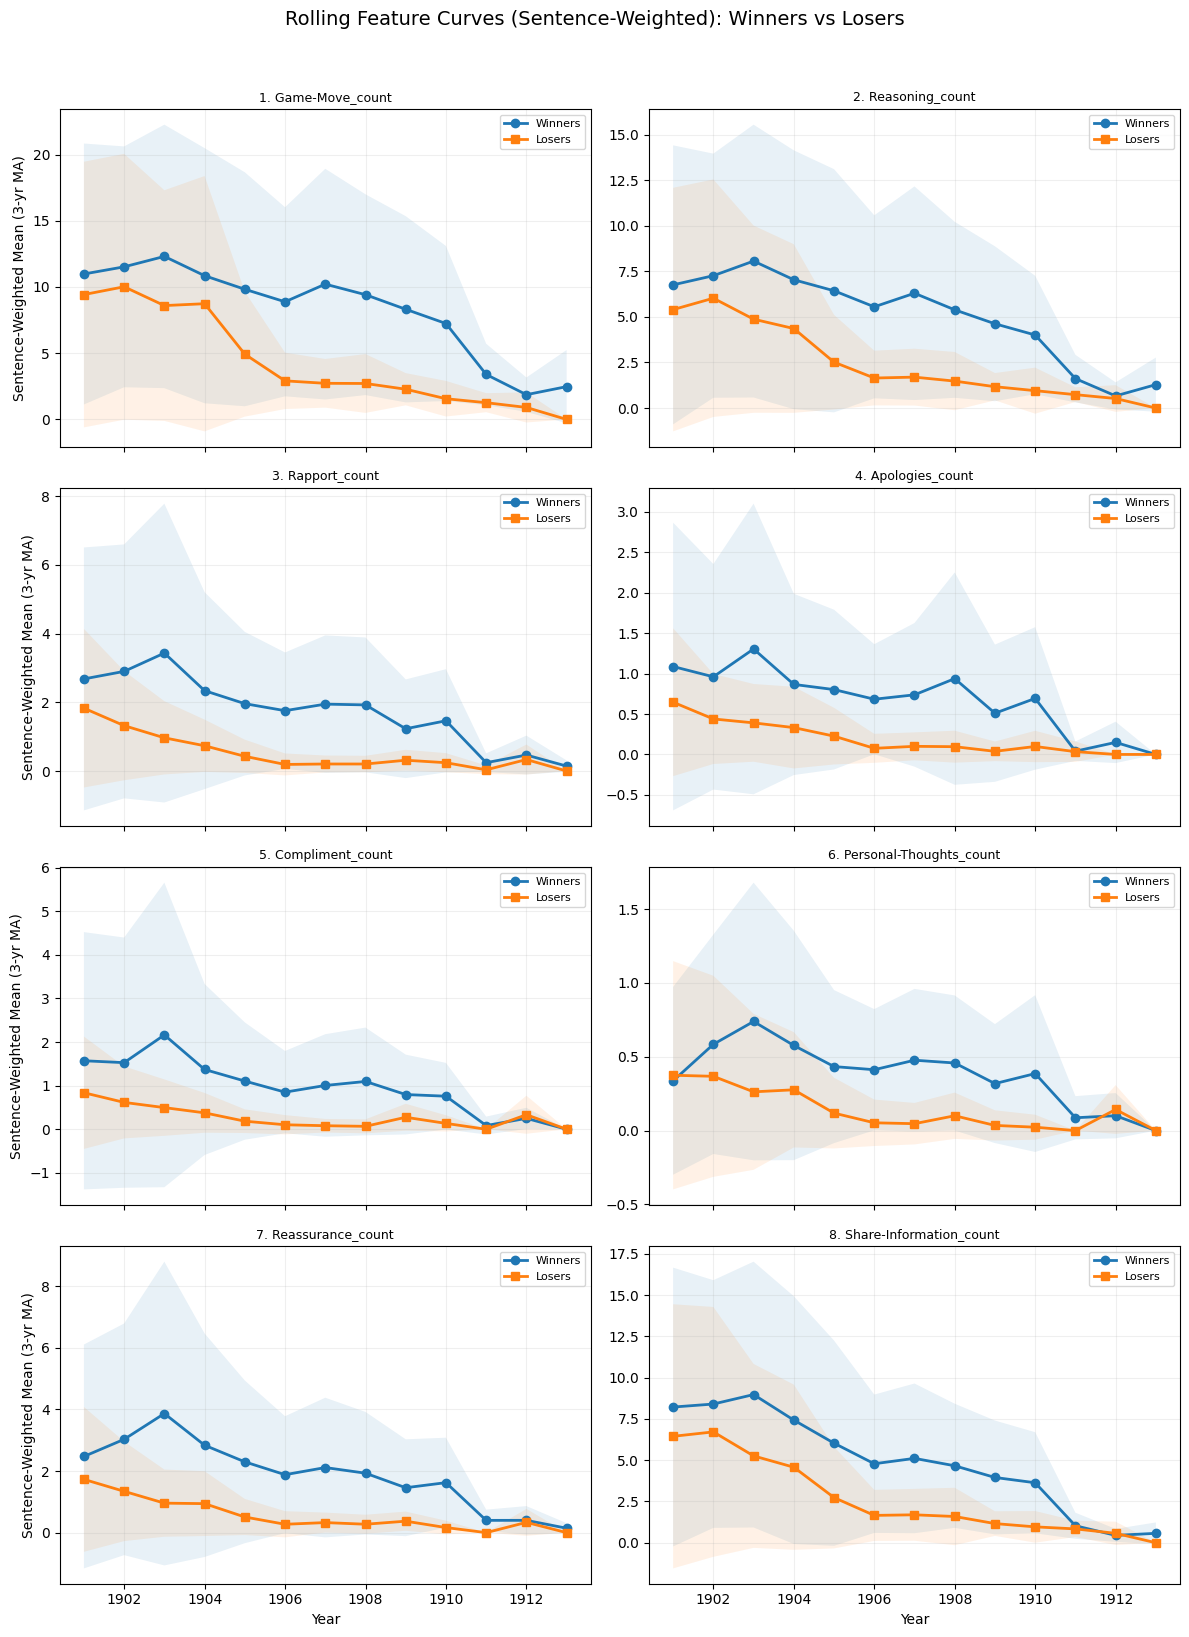

In [69]:
# ============================================
# 新增：赢家 vs 败者 的对比曲线（基于句子加权平均）
# ============================================
def _yearly_sentence_weighted_mean_std(df, feature_cols, supply_col, year_col, sentence_col="all_messages_sentence_count"):
    """
    内部工具：返回按年聚合后的 sentence-weighted mean/std DataFrame
    - mean: sum(feature * sentence_count) / sum(sentence_count)
    - std: sqrt( sum(sentence_count * (feature - mean)^2) / sum(sentence_count) )
    """
    # 先确保所有需要的列都存在
    df = df.copy()
    if sentence_col not in df.columns:
        raise ValueError(f"DataFrame 缺少 {sentence_col} 列")
    # 计算每个 feature * sentence_count
    for c in feature_cols:
        df[f"roll_{c}_x_sentence"] = df[f"roll_{c}"] * df[sentence_col]
    # 计算 supply * sentence_count
    df[f"{supply_col}_x_sentence"] = df[supply_col] * df[sentence_col]

    def weighted_mean_std(group, value_col, weight_col):
        v = group[value_col]
        w = group[weight_col]
        mean = (v * w).sum() / w.sum() if w.sum() > 0 else np.nan
        # weighted std: sqrt( sum(w * (v-mean)^2) / sum(w) )
        std = np.sqrt(((w * (v - mean) ** 2).sum()) / w.sum()) if w.sum() > 0 else np.nan
        return pd.Series({"mean": mean, "std": std})

    results = []
    for year, group in df.groupby(year_col):
        row = {year_col: year}
        # supply
        res = weighted_mean_std(group, supply_col, sentence_col)
        row[f"mean_{supply_col}"] = res["mean"]
        row[f"std_{supply_col}"] = res["std"]
        # features
        for c in feature_cols:
            res_feat = weighted_mean_std(group, f"roll_{c}", sentence_col)
            row[f"mean_roll_{c}"] = res_feat["mean"]
            row[f"std_roll_{c}"] = res_feat["std"]
        results.append(row)
    return pd.DataFrame(results)

def plot_mean_curves_sentence_weight_compare(
    df_win, df_loss, *,                   # 已 preprocess 的 DF
    feature_cols=FEATURE_COLS,
    supply_col=SUPPLY_COL,
    year_col=YEAR_COL,
    label_win="Winners", label_loss="Losers",
    sentence_col="all_messages_sentence_count"
):
    """
    把 winner / loser 的平均 Supply & Feature 曲线画在同一张图上。
    均值为 sentence-weighted mean。
    先调用 preprocess，再传进来！
    """
    # --------- 计算sentence加权均值与方差 ---------
    mean_win  = _yearly_sentence_weighted_mean_std(df_win,  feature_cols, supply_col, year_col, sentence_col)
    mean_loss = _yearly_sentence_weighted_mean_std(df_loss, feature_cols, supply_col, year_col, sentence_col)

    # --------- ① Supply 对比 ---------
    plt.figure(figsize=(8, 5))
    plt.plot(mean_win[year_col],  mean_win[f"mean_{supply_col}"],
             marker="o", label=f"{label_win} (mean)",  linewidth=2)
    plt.plot(mean_loss[year_col], mean_loss[f"mean_{supply_col}"],
             marker="s", label=f"{label_loss} (mean)", linewidth=2)
    # 阴影显示 ±1 std
    plt.fill_between(mean_win[year_col],
                     mean_win[f"mean_{supply_col}"]  - mean_win[f"std_{supply_col}"],
                     mean_win[f"mean_{supply_col}"]  + mean_win[f"std_{supply_col}"],
                     alpha=0.15)
    plt.fill_between(mean_loss[year_col],
                     mean_loss[f"mean_{supply_col}"] - mean_loss[f"std_{supply_col}"],
                     mean_loss[f"mean_{supply_col}"] + mean_loss[f"std_{supply_col}"],
                     alpha=0.15)
    plt.xlabel("Year"); plt.ylabel("Supply Centers (sentence-weighted mean)")
    plt.title("Mean Supply Centers (Sentence-Weighted): Winners vs Losers")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # --------- ② 各特征对比 ---------
    n = len(feature_cols); ncols = 2; nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    for i, feat in enumerate(feature_cols):
        ax = axes[i]
        w_mean = mean_win [f"mean_roll_{feat}"]; w_std = mean_win [f"std_roll_{feat}"]
        l_mean = mean_loss[f"mean_roll_{feat}"]; l_std = mean_loss[f"std_roll_{feat}"]
        ax.plot(mean_win[year_col],  w_mean, marker="o", label=label_win,  linewidth=2)
        ax.plot(mean_loss[year_col], l_mean, marker="s", label=label_loss, linewidth=2)
        ax.fill_between(mean_win[year_col],  w_mean-w_std, w_mean+w_std, alpha=.10)
        ax.fill_between(mean_loss[year_col], l_mean-l_std, l_mean+l_std, alpha=.10)
        ax.set_title(feat, fontsize=9); ax.grid(alpha=.2)
        if i % ncols == 0: ax.set_ylabel("Sentence-Weighted Mean (3-yr MA)")
        if i // ncols == nrows-1: ax.set_xlabel("Year")
        ax.legend(fontsize=8)
    # 清掉空白子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Rolling Feature Curves (Sentence-Weighted): Winners vs Losers", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()


# ============================================
# DEMO: 在主函数里调用
# ============================================
if __name__ == "__main__":
    # 假设你已经在 Notebook / 脚本里准备好 df_winner_yearly 和 df_loser_yearly
    if "df_winner_yearly" not in globals() or "df_loser_yearly" not in globals():
        raise ValueError("请先定义 df_winner_yearly 与 df_loser_yearly！")

    # 1) 预处理
    df_win_proc  = preprocess(df_winner_yearly)
    df_loss_proc = preprocess(df_loser_yearly)

    # 2) 赢家-败者平均曲线对比（基于句子加权平均）
    plot_mean_curves_sentence_weight_compare(df_win_proc, df_loss_proc)

    # 其它分析（如滞后相关、分段占比等）也可以分别对 df_win_proc / df_loss_proc 调用


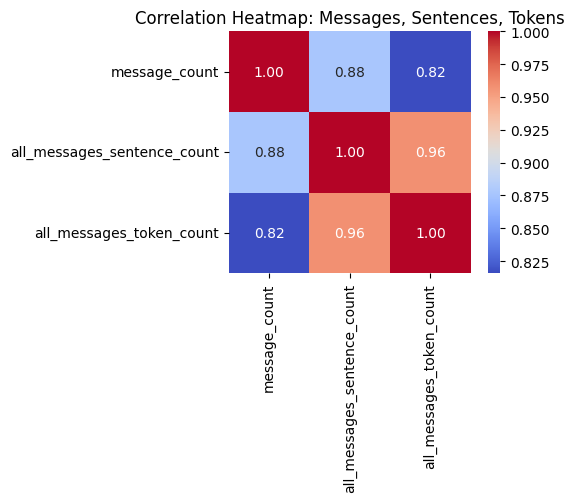

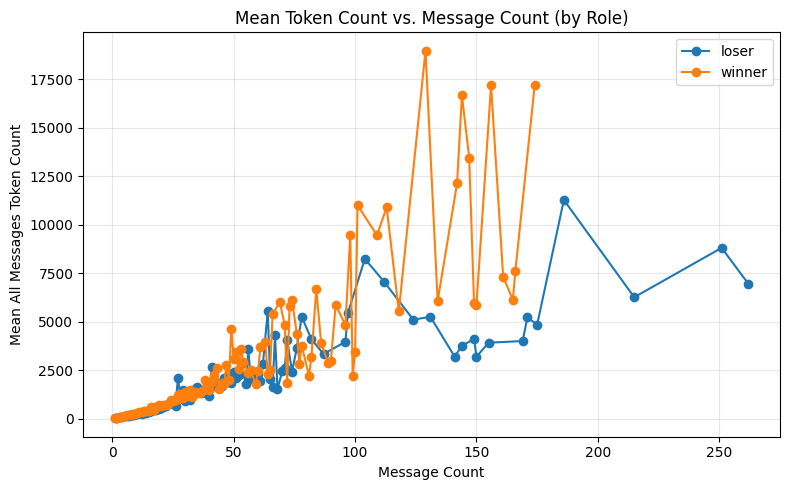

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# 假设 df_win_proc 和 df_loss_proc 都有 'message_count', 'all_messages_sentence_count', 'all_messages_token_count' 这三列
# 合并赢家和败者数据，加一列标记
df_win_proc['role'] = 'winner'
df_loss_proc['role'] = 'loser'
df_all = pd.concat([df_win_proc, df_loss_proc], ignore_index=True)

# 只关注这三列的相关性
cols = ['message_count', 'all_messages_sentence_count', 'all_messages_token_count']

# 1. 用heatmap画相关性矩阵
corr = df_all[cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap: Messages, Sentences, Tokens')
plt.tight_layout()
plt.show()

# 2. 画曲线（均值趋势），比如 message_count 和 all_messages_token_count 的关系
plt.figure(figsize=(8, 5))
for role, group in df_all.groupby('role'):
    # 按 message_count 分组，画均值曲线
    grouped = group.groupby('message_count')['all_messages_token_count'].mean().reset_index()
    plt.plot(grouped['message_count'], grouped['all_messages_token_count'], marker='o', label=role)
plt.xlabel('Message Count')
plt.ylabel('Mean All Messages Token Count')
plt.title('Mean Token Count vs. Message Count (by Role)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
